In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
#import numpy as np
import cartopy.feature as feature

In [2]:
#path_sm = '/g/data/jk72/sm3719/'
#path_cmip = 'cmip6'
#path_ds = '/pictrl/CSIRO-MK3-6-0/climate_index/eof/IOBM-IOD/eof2_CSIRO-Mk3-6-0-iobm_kave.nc'

#xr.open_dataset(path_sm + path_cmip)

In [3]:
ds1=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/SDM/Regression_OHC_spatial_pattern_SDM_ORAS5-23models.nc')
ds2=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/SDM/Regression_OHC_spatial_pattern_SDM_MMM.nc')

SDM1=ds1['SLOPE_M'][0,:,:]/1e8
SDM2=ds1['SLOPE_M'][1,:,:]/1e8
SDM3=ds1['SLOPE_M'][2,:,:]/1e8
SDM4=ds1['SLOPE_M'][3,:,:]/1e8
SDM5=ds1['SLOPE_M'][4,:,:]/1e8
SDM6=ds1['SLOPE_M'][5,:,:]/1e8
SDM7=ds1['SLOPE_M'][6,:,:]/1e8
SDM8=ds1['SLOPE_M'][7,:,:]/1e8
SDM9=ds1['SLOPE_M'][8,:,:]/1e8
SDM10=ds1['SLOPE_M'][9,:,:]/1e8

print(ds1.coords)
LON = ds1.LON.data
LAT = ds1.LAT.data
LON=np.linspace(40,110,71)
LAT=np.linspace(-20,25,45)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)

Coordinates:
  * TIME     (TIME) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 568B 40.0 41.0 42.0 43.0 ... 107.0 108.0 109.0 110.0
  * LAT      (LAT) float64 360B -19.45 -18.45 -17.45 ... 22.44 23.43 24.43


In [4]:
SDM11=ds1['SLOPE_M'][10,:,:]/1e8
SDM12=ds1['SLOPE_M'][11,:,:]/1e8
SDM13=ds1['SLOPE_M'][12,:,:]/1e8
SDM14=ds1['SLOPE_M'][13,:,:]/1e8
SDM15=ds1['SLOPE_M'][14,:,:]/1e8
SDM16=ds1['SLOPE_M'][15,:,:]/1e8
SDM17=ds1['SLOPE_M'][16,:,:]/1e8
SDM18=ds1['SLOPE_M'][17,:,:]/1e8
SDM19=ds1['SLOPE_M'][18,:,:]/1e8
SDM20=ds1['SLOPE_M'][19,:,:]/1e8
SDM21=ds1['SLOPE_M'][20,:,:]/1e8
SDM22=ds1['SLOPE_M'][21,:,:]/1e8
SDM23=ds1['SLOPE_M'][22,:,:]/1e8
SDM24=ds1['SLOPE_M'][23,:,:]/1e8
SDM25=ds2['MMM'][:,:]/1e8
SDM19.shape

(45, 71)

In [5]:
datasets = [
    (SDM1, "(a) ORAS5 (EOF1-21.0%)"),
    (SDM2, "(b) CanESM5 (EOF1-17.5%)"),
    (SDM3, "(c) HadGEM3-GC31-LL (EOF1-32.3%)"),
    (SDM4, "(d) EC-Earth3-CC (EOF1-34.8%)"),
    (SDM5, "(e) CMCC-CM2-SR5 (EOF1-30.3%)"),
    (SDM6, "(f) CNRM-CM6-1 (EOF1-28.8%)"),
    (SDM7, "(g) GISS-E2-1-G (EOF1-44.3%)"),
    (SDM8, "(h) CMCC-ESM2 (EOF1-37.8%)"),
    (SDM9, "(i) EC-Earth3 (EOF1-32.6%)"),
    (SDM10, "(j) E3SM1-0 (EOF1-27.6%)"),
    (SDM11, "(k) MIROC6 (EOF1-30.1%)"),
    (SDM12, "(l) MRI-ESM2-0 (EOF1-29.4%)"),
    (SDM13, "(m) HadGEM3-GC31-MM (EOF1-14.4%)"),
    (SDM14, "(n) BCC-CSM2-MR (EOF1-26.1%)"),
    (SDM15, "(o) IPSL-CM6A-LR (EOF1-23.1%)"),
    (SDM16, "(p) MPI-ESM1-2-HR (EOF1-19.7%)"),
    (SDM17, "(q) ACCESS-ESM1-5 (EOF1-23.7%)"),
    (SDM18, "(r) ACCESS-CM2 (EOF1-21.6%)"),
    (SDM19, "(s) CESM2 (EOF1-39.3%)"),
    (SDM20, "(t) GFDL-CM4 (EOF1-17.0%)"),
    (SDM21, "(u) CIESM (EOF1-42.0%)"),
    (SDM22, "(v) FGOALS-g3 (EOF1-41.0%)"),
    (SDM23, "(w) SAM0-UNICON (EOF1-38.5%)"),
    (SDM24, "(x) CNRM-ESM2-1 (EOF1-29.1%)"),
    (SDM25, "(y) MMM")
]

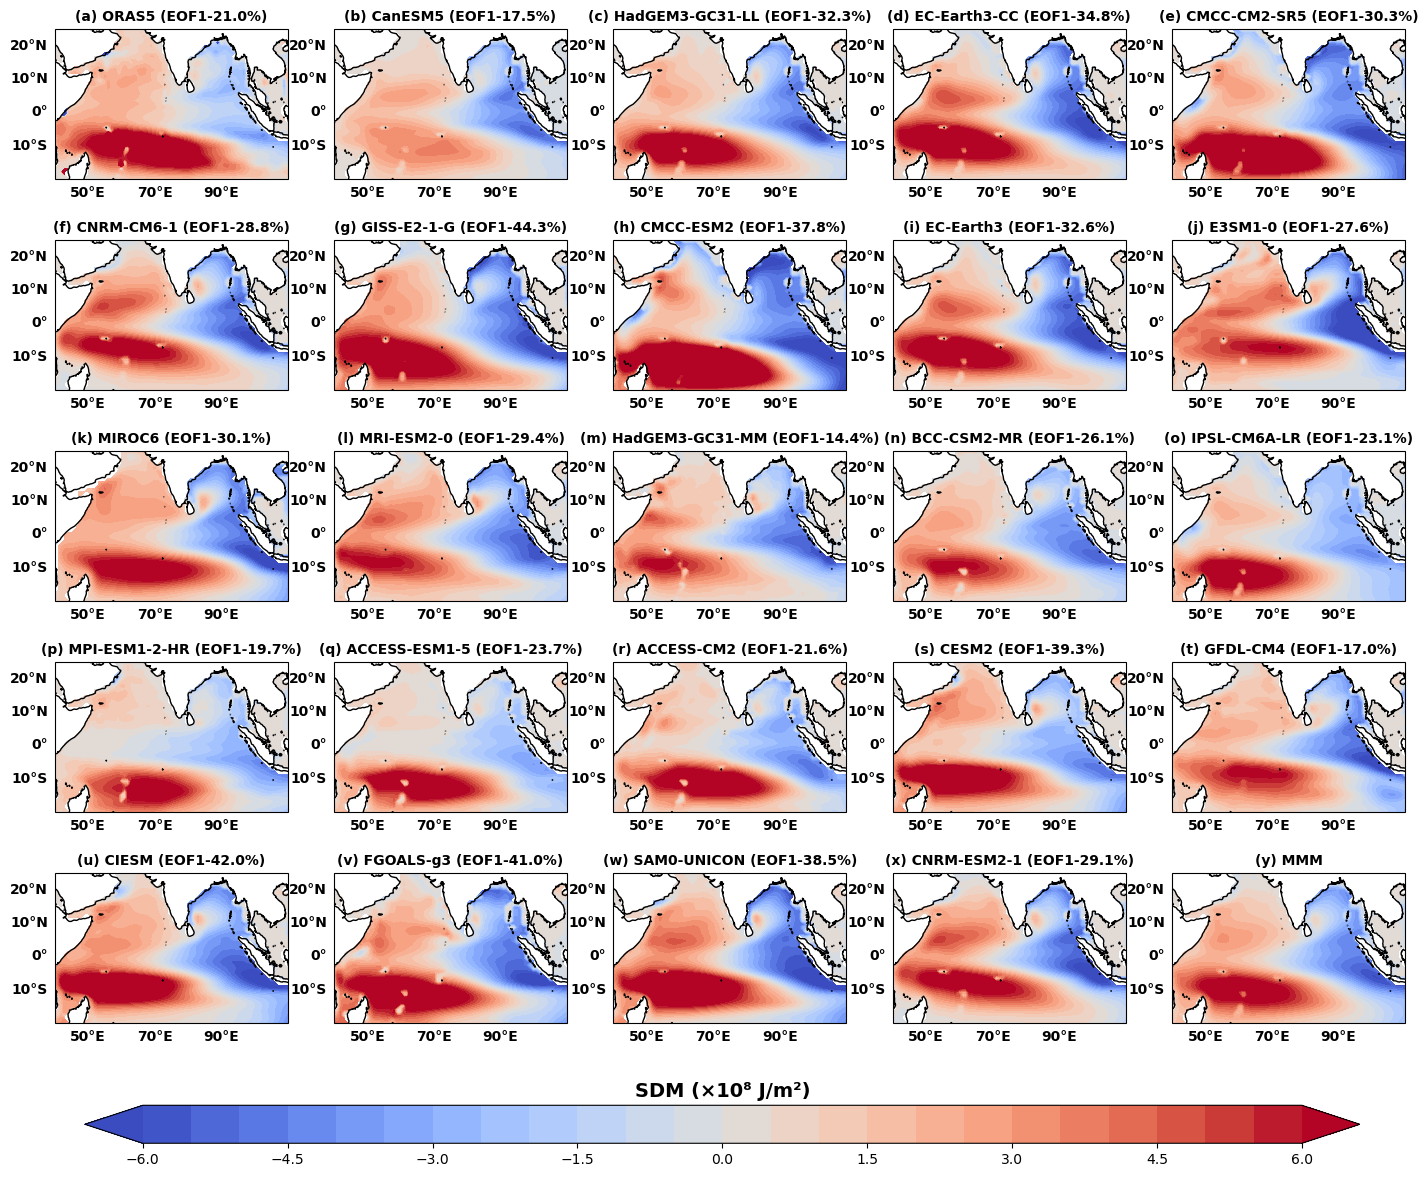

In [10]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.PlateCarree(central_longitude=75)
clevs = np.arange(-6.0, 6.5, 0.5)

# Create figure
fig = plt.figure(figsize=(15, 19))
# Store the last `contourf` plot for the colorbar
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(LON, LAT, data, levels=clevs, cmap=plt.cm.coolwarm,transform=ccrs.PlateCarree(), extend='both')
    last_fill_sf = fill_sf  # Update the last contourf object
    ax.set_aspect('equal')
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')
    #ax.annotate(annotation, xy=(0.5, -0.15), xycoords='axes fraction', ha='center', va='top', fontsize=10, color='red', fontweight='bold')
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# --- Longitude labels ---
    gl.top_labels = False       # no longitude labels on top
    gl.bottom_labels = True     # show longitude labels only on the bottom
# --- Latitude labels ---
    gl.left_labels = True       # keep latitude labels on the left
    gl.right_labels = False     # no latitude labels on the right
# --- Gridline drawing ---
    gl.xlines = False           # don't draw the longitude gridlines themselves
    gl.ylines = False           # don't draw the latitude gridlines themselves
# --- Formatters ---
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Adjust layout (moved outside the `if` block)
plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

# Add colorbar
if last_fill_sf is not None:  # Check if a valid contourf object exists
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])  # Adjust these values for proper placement
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('SDM (×10⁸ J/m²)', loc='center', color='black', fontsize=14, fontweight='bold')

# Save and show plot
plt.savefig('/g/data/jk72/sm3719/cmip6/ESSD/climate_mode/panel25_regression_regression_SDM_models_observations_mmm.png', dpi=600)
plt.show()